In [ ]:
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [23]:
import warnings
warnings.filterwarnings("ignore")

#!pip install pyyaml

# Camadas de Convolução

In [27]:

import os
import numpy as np
import cv2
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, 
    MaxPooling2D, AveragePooling2D, GlobalAveragePooling2D, 
    Dense, Dropout, ZeroPadding2D, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD

# Fixando o eixo de concatenação (canais por último no TensorFlow/Kaggle)
concat_axis = 3

def conv_block(x, stage, branch, nb_filter, dropout_rate=None):
    '''Apply BatchNorm, Relu, bottleneck 1x1 Conv2D, 3x3 Conv2D, and optional dropout '''
    
    # 1x1 Convolution (Bottleneck layer)
    inter_channel = nb_filter * 4  
    x = BatchNormalization(axis=concat_axis)(x)
    x = Activation('relu')(x)
    # Atualizado: Conv2D com sintaxe moderna (filtros, tamanho do kernel)
    x = Conv2D(inter_channel, (1, 1), use_bias=False)(x)

    if dropout_rate:
        x = Dropout(dropout_rate)(x)

    # 3x3 Convolution
    x = BatchNormalization(axis=concat_axis)(x)
    x = Activation('relu')(x)
    x = ZeroPadding2D((1, 1))(x)
    x = Conv2D(nb_filter, (3, 3), use_bias=False)(x)

    if dropout_rate:
        x = Dropout(dropout_rate)(x)

    return x

def transition_block(x, stage, nb_filter, dropout_rate=None):
    ''' Apply BatchNorm, 1x1 Convolution, averagePooling, optional compression, dropout '''
    x = BatchNormalization(axis=concat_axis)(x)
    x = Activation('relu')(x)
    x = Conv2D(int(nb_filter), (1, 1), use_bias=False)(x)

    if dropout_rate:
        x = Dropout(dropout_rate)(x)

    x = AveragePooling2D((2, 2), strides=(2, 2))(x)
    return x

def dense_block(x, stage, nb_layers, nb_filter, growth_rate, dropout_rate=None, grow_nb_filters=True):
    ''' Build a dense_block where the output of each conv_block is fed to subsequent ones '''
    concat_feat = x

    for i in range(nb_layers):
        branch = i + 1
        x = conv_block(concat_feat, stage, branch, growth_rate, dropout_rate)
        # Garantindo o uso da camada Concatenate moderna
        concat_feat = Concatenate(axis=concat_axis)([concat_feat, x])

        if grow_nb_filters:
            nb_filter += growth_rate

    return concat_feat, nb_filter

# Arquitetura Densenet (Unused)

In [ ]:
#def densenet121_model(num_classes=3):
#    ''' Reconstruindo a densenet121_model com a sintaxe correta '''
#    img_input = Input(shape=(224, 224, 3), name='data')
#    
#    nb_filter = 64
#    nb_layers = [6, 12, 24, 16] # Configuração padrão 121
#
#    # Convolução Inicial
#    # Atualizado: subsample virou strides; kernel 7x7 definido como (7,7)
#    x = Conv2D(nb_filter, (7, 7), strides=(2, 2), name='conv1', use_bias=False, padding='same')(img_input)
#    x = BatchNormalization(axis=concat_axis)(x)
#    x = Activation('relu')(x)
#    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
#
#    # Adicionando os blocos densos
#    for block_idx in range(len(nb_layers) - 1):
#        stage = block_idx + 2
#        x, nb_filter = dense_block(x, stage, nb_layers[block_idx], nb_filter, growth_rate=32)
#        x = transition_block(x, stage, nb_filter)
#
#    final_stage = stage + 1
#    x, nb_filter = dense_block(x, final_stage, nb_layers[-1], nb_filter, growth_rate=32)
#
#
#    x = BatchNormalization(axis=concat_axis)(x)
#    x = Activation('relu')(x)
#
#    # Camadas Finais de Classificação
#    x_fc = GlobalAveragePooling2D()(x)
#    x_fc = Dense(num_classes, activation='softmax')(x_fc)
#
#    model = Model(img_input, x_fc)
#
#    # Otimizador com sintaxe moderna (learning_rate em vez de lr)
#    sgd = SGD(learning_rate=1e-3, momentum=0.9, nesterov=True)
#    model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])
#
#    return model

# Preparação do Dataset

In [33]:
import os
import numpy as np
import cv2
import random
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import img_to_array

def load_data(base_path):
    data = []
    labels = []
    
    categories = sorted(os.listdir(base_path)) 
    print(f"Categorias encontradas: {categories}")
    
    for category in categories:
        path = os.path.join(base_path, category)
        if not os.path.isdir(path): 
            continue
        
        print(f"Carregando imagens de: {category}...")
        
        for img_name in os.listdir(path):
            try:
                img_path = os.path.join(path, img_name)
                image = cv2.imread(img_path)
                
                # --- MELHORIA PARA RAIO-X (CLAHE) ---
                image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
                image = clahe.apply(image)
                image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB) # DenseNet exige 3 canais
                # ------------------------------------
                
                image = cv2.resize(image, (224, 224))
                image = img_to_array(image)
                data.append(image)
                labels.append(category)
            except Exception as e:
                # Pula arquivos que não sejam imagens (ex: .DS_Store ou corrompidos)
                continue
                
    # Normalização e conversão para arrays numpy
    data = np.array(data, dtype="float32") / 255.0
    labels = np.array(labels)
    
    # Transforma nomes (Strings) em vetores numéricos One-Hot
    mlb = LabelBinarizer()
    labels = mlb.fit_transform(labels)
    
    print(f"Total de imagens carregadas: {len(data)}")
    return data, labels

from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

#train_path = "/kaggle/input/datasets/jppb2005/test-pneumo/Dataset/train"
#test_path = "/kaggle/input/datasets/jppb2005/test-pneumo/Dataset/test"

train_path = "/kaggle/input/datasets/mos3santos/imagens-de-radiografia-de-trax-pneumonia/chest_xray/train"
test_path = "/kaggle/input/datasets/mos3santos/imagens-de-radiografia-de-trax-pneumonia/chest_xray/test"
val_path = "/kaggle/input/datasets/mos3santos/imagens-de-radiografia-de-trax-pneumonia/chest_xray/val"

# Carregamento
X_train_full, Y_train_full = load_data(train_path)
X_test, Y_test = load_data(test_path)
X_valid, Y_valid = load_data(val_path)

## Criando a Validação (20% do treino)
#(X_train, X_valid, Y_train, Y_valid) = train_test_split(
#    X_train_full, Y_train_full, test_size=0.20, random_state=42
#)

# Se o seu Y_train tem apenas uma coluna (shape N, 1), vamos forçar para 2 colunas
if Y_train_full.shape[1] == 1:
    # Isso transforma [0, 1, 0] em [[1,0], [0,1], [1,0]]
    Y_train_full = to_categorical(Y_train_full, num_classes=2)
    Y_test = to_categorical(Y_test, num_classes=2)
    Y_valid = to_categorical(Y_valid, num_classes=2)

# Redivida ou atualize as variáveis se necessário
X_train, X_valid, Y_train, Y_valid = train_test_split(X_train_full, Y_train_full, test_size=0.2, random_state=42)


print("Estrutura final dos dados:")
print(f"Treino: {X_train.shape}")
print(f"Validação: {X_valid.shape}")
print(f"Teste: {X_test.shape}")

Categorias encontradas: ['NORMAL', 'PNEUMONIA']
Carregando imagens de: NORMAL...
Carregando imagens de: PNEUMONIA...
Total de imagens carregadas: 5216
Categorias encontradas: ['NORMAL', 'PNEUMONIA']
Carregando imagens de: NORMAL...
Carregando imagens de: PNEUMONIA...
Total de imagens carregadas: 624
Categorias encontradas: ['NORMAL', 'PNEUMONIA']
Carregando imagens de: NORMAL...
Carregando imagens de: PNEUMONIA...
Total de imagens carregadas: 16
Estrutura final dos dados:
Treino: (4172, 224, 224, 3)
Validação: (1044, 224, 224, 3)
Teste: (624, 224, 224, 3)


# Setup de treinamento

In [34]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

if __name__ == '__main__':
    num_classes = 2 
    batch_size = 32
    nb_epoch = 50 
    filepath = "/kaggle/working/bestmodel.keras"

    # 1. Criar o modelo com a saída correta (Dense 2)
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=predictions)

    # 2. Compilar
    model.compile(optimizer=SGD(learning_rate=1e-4, momentum=0.9), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])

    # 3. Callbacks
    checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # 4. Treinar
    history = model.fit(
        train_datagen.flow(X_train, Y_train, batch_size=batch_size),
        steps_per_epoch=len(X_train) // batch_size,
        epochs=nb_epoch,
        validation_data=(X_valid, Y_valid),
        callbacks=[checkpoint, early_stop],
        verbose=1
    )

Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 923ms/step - accuracy: 0.7211 - loss: 0.5206
Epoch 1: val_accuracy improved from -inf to 0.72510, saving model to /kaggle/working/bestmodel.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.7220 - loss: 0.5193 - val_accuracy: 0.7251 - val_loss: 0.8196
Epoch 2/50
  1/130 ━━━━━━━━━━━━━━━━━━━━ 45s 352ms/step - accuracy: 0.9688 - loss: 0.1483
Epoch 2: val_accuracy did not improve from 0.72510
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9688 - loss: 0.1483 - val_accuracy: 0.7251 - val_loss: 0.8226
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.9332 - loss: 0.1816
Epoch 3: val_accuracy improved from 0.72510 to 0.72701, saving model to /kaggle/working/bestmodel.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 46s 353ms/step - accuracy: 0.9332 - loss: 0.1815 - val_accuracy: 0.7270 - val_loss: 0.7925
Epoch 4/50
  1/130 ━━━━━━━━━━━━━━━━━━━━ 35s 279ms/step - accuracy: 0.9375 - loss: 0.1510
Epoch 4: val_accuracy did not impr

# Avaliação de Acurácia e Perda do modelo

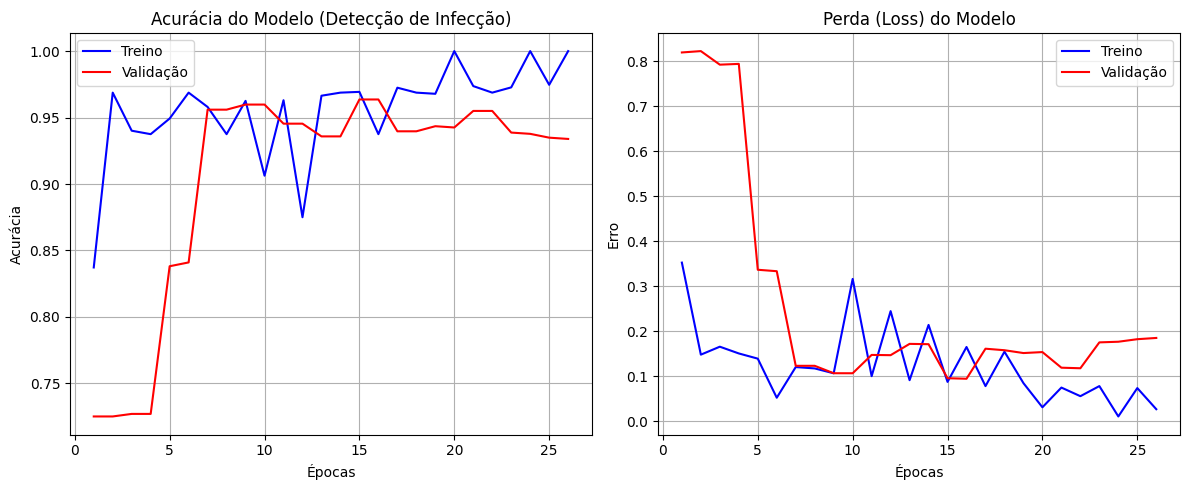

In [35]:
%matplotlib inline
import matplotlib.pyplot as plt

# Verificação automática das chaves (evita o KeyError)
acc = history.history.get('accuracy') or history.history.get('acc')
val_acc = history.history.get('val_accuracy') or history.history.get('val_acc')
loss = history.history.get('loss')
val_loss = history.history.get('val_loss')

epochs = range(1, len(acc) + 1)

#Gráfico de Acurácia
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Treino')
plt.plot(epochs, val_acc, 'r', label='Validação')
plt.title('Acurácia do Modelo (Detecção de Infecção)')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

#Gráfico de Perda
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Treino')
plt.plot(epochs, val_loss, 'r', label='Validação')
plt.title('Perda (Loss) do Modelo')
plt.xlabel('Épocas')
plt.ylabel('Erro')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Testes de Predição

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step


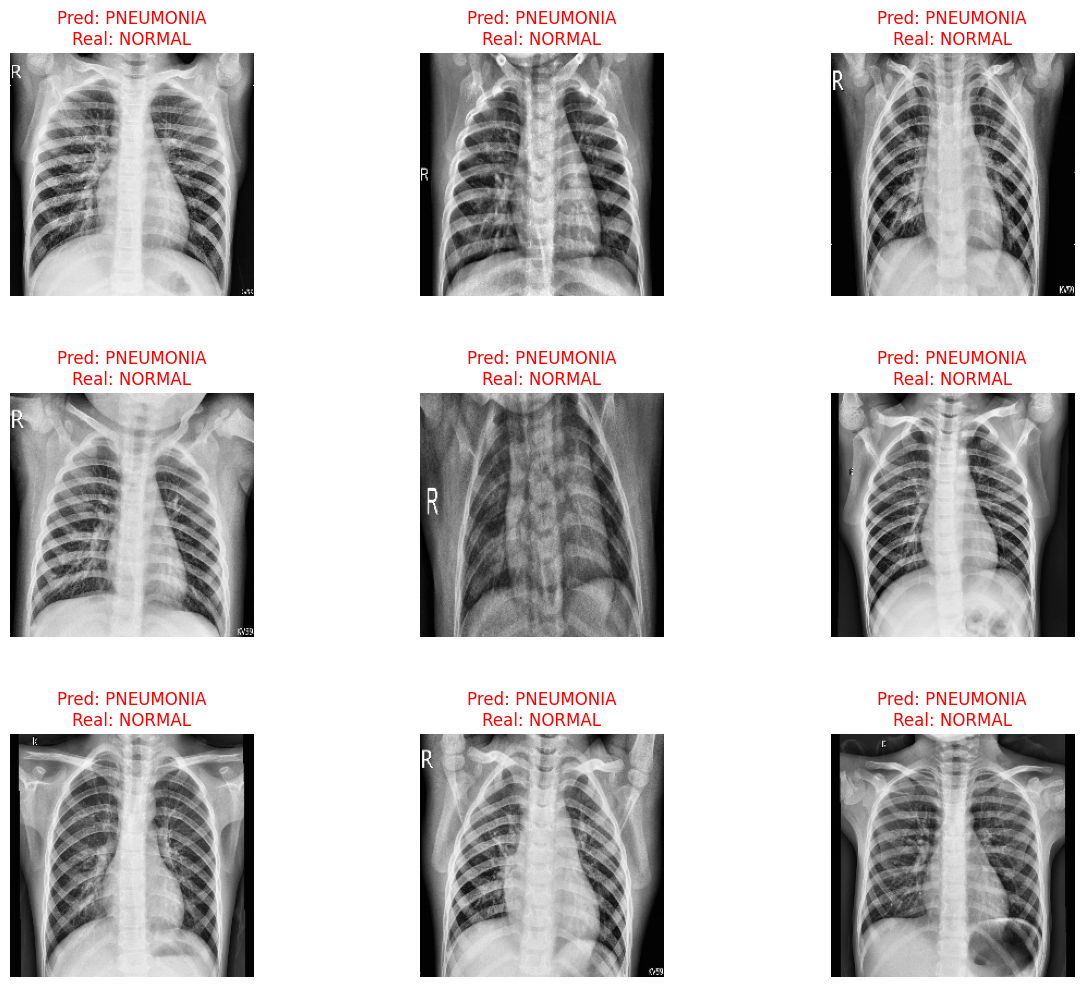

In [37]:
import random
import numpy as np
import matplotlib.pyplot as plt

# 1. Ajustando os labels para o seu dataset de Raio-X
# Certifique-se de que a ordem aqui é a mesma das suas pastas
labels = ['NORMAL', 'PNEUMONIA']

# 2. Gerando as predições para o conjunto de teste
ypred = model.predict(X_test)

# 3. Identificando acertos e erros para análise
accurate_indices = []
wrong_indices = []

for i in range(len(Y_test)):
    if np.argmax(ypred[i]) == np.argmax(Y_test[i]):
        accurate_indices.append(i)
    else:
        wrong_indices.append(i)

# 4. Escolha o que quer visualizar: accurate_indices ou wrong_indices
# Vamos visualizar 9 erros, que é onde o pesquisador mais aprende sobre o modelo
sample_indices = random.sample(wrong_indices, k=min(9, len(wrong_indices)))

#sample_indices = random.sample(accurate_indices, k=min(9, len(accurate_indices)))

nrows, ncols = 3, 3
fig, ax = plt.subplots(nrows, ncols, figsize=(15, 12))
plt.subplots_adjust(hspace=0.4) # Espaço para ler os títulos

n = 0
for row in range(nrows):
    for col in range(ncols):
        if n < len(sample_indices):
            idx = sample_indices[n]
            
            # Mostra a imagem (X_test)
            ax[row,col].imshow(X_test[idx])
            
            # Pega os nomes das classes
            pred_name = labels[np.argmax(ypred[idx])]
            true_name = labels[np.argmax(Y_test[idx])]
            
            # Define a cor do título: Verde se acertou, Vermelho se errou
            color = 'green' if pred_name == true_name else 'red'
            
            ax[row,col].set_title(f"Pred: {pred_name}\nReal: {true_name}", color=color, fontsize=12)
            ax[row,col].axis('off') # Remove os eixos para focar na imagem
            n += 1

plt.show()